In [1]:
# Install & Import
!pip install kagglehub --quiet

import os, shutil, time, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
from skimage.feature import hog

import tensorflow as tf
from tensorflow.keras import layers, models
import joblib

In [3]:
#Mount Drive & Download Dataset
from google.colab import drive
drive.mount('/content/drive')

import kagglehub
path = kagglehub.dataset_download("olgabelitskaya/flower-color-images")
print("Path dataset:", path)

Mounted at /content/drive


100%|██████████| 50.1M/50.1M [00:00<00:00, 126MB/s]

Extracting files...


Path dataset: /root/.cache/kagglehub/datasets/olgabelitskaya/flower-color-images/versions/7


In [4]:
#Mapping Path

DATASET_DIR = path
OUTPUT_DIR  = "/content/drive/MyDrive/Computer Vision/Tugas 3/output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["merah", "orange", "kuning", "biru", "ungu", "pink", "putih"]
IMG_SIZE    = 128

print(f"Dataset : {DATASET_DIR}")
print(f"Output  : {OUTPUT_DIR}")

Dataset : /root/.cache/kagglehub/datasets/olgabelitskaya/flower-color-images/versions/7
Output  : /content/drive/MyDrive/Computer Vision/Tugas 3/output


In [5]:
# Fungsi Pelabelan HSV

COLOR_RANGES = {
    "merah":  [(np.array([0,   120,  80]), np.array([8,   255, 255])),
               (np.array([172, 120,  80]), np.array([179, 255, 255]))],
    "orange": [(np.array([9,   120,  80]), np.array([20,  255, 255]))],
    "kuning": [(np.array([21,  100,  80]), np.array([35,  255, 255]))],
    "biru":   [(np.array([90,   60,  50]), np.array([125, 255, 255]))],
    "ungu":   [(np.array([126,  40,  40]), np.array([148, 255, 255]))],
    "pink":   [(np.array([149,  40,  80]), np.array([171, 255, 255]))],
    "putih":  [(np.array([0,     0, 190]), np.array([179,  30, 255]))],
}

def get_flower_mask(img):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(mask, (w//2, h//2), (w//3, h//3), 0, 0, 360, 255, -1)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    green = cv2.inRange(hsv, np.array([36, 40,  40]), np.array([85,  255, 255]))
    sky   = cv2.inRange(hsv, np.array([90, 30, 150]), np.array([130, 255, 255]))
    exclude = cv2.bitwise_or(green, sky)
    return cv2.bitwise_and(mask, cv2.bitwise_not(exclude))

def label_image(img):
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    fmask = get_flower_mask(img)
    scores = {}
    for name, ranges in COLOR_RANGES.items():
        total = 0
        for lo, hi in ranges:
            m = cv2.inRange(hsv, lo, hi)
            total += cv2.countNonZero(cv2.bitwise_and(m, fmask))
        scores[name] = total
    sorted_s = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top1_name, top1_val = sorted_s[0]
    top2_val = sorted_s[1][1]
    if top1_val < 300 or (top2_val > 0 and top1_val / top2_val < 1.5):
        return None
    return top1_name

In [6]:
#Load & Labeling Dataset

images, labels = [], []
skipped = 0

all_files = []
for root, dirs, files_in in os.walk(DATASET_DIR):
    for fname in files_in:
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            all_files.append(os.path.join(root, fname))

print(f"Total file ditemukan: {len(all_files)}")

for fpath in all_files:
    img = cv2.imread(fpath)
    if img is None:
        continue
    img   = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    label = label_image(img)
    if label is None:
        skipped += 1
        continue
    images.append(img)
    labels.append(CLASS_NAMES.index(label))

images = np.array(images)
labels = np.array(labels)

print(f"\nTotal terlabel       : {len(images)}")
print(f"Tidak terklasifikasi : {skipped}")
print("\nDistribusi kelas:")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:8s}: {np.sum(labels == i)}")

Total file ditemukan: 813

Total terlabel       : 729
Tidak terklasifikasi : 84

Distribusi kelas:
  merah   : 79
  orange  : 57
  kuning  : 136
  biru    : 12
  ungu    : 73
  pink    : 147
  putih   : 225


In [7]:
# Data Split

X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
print(f"Train : {len(X_train)}")
print(f"Test  : {len(X_test)}")

Train : 583
Test  : 146


In [8]:
# Training Metode 1: SVM + HOG

def extract_hog(imgs):
    features = []
    for img in imgs:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feat = hog(gray,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   visualize=False)
        features.append(feat)
    return np.array(features)

print("Ekstraksi HOG — training set...")
X_train_hog = extract_hog(X_train)
print("Ekstraksi HOG — test set...")
X_test_hog  = extract_hog(X_test)
print(f"Dimensi fitur HOG : {X_train_hog.shape[1]}")

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=10, gamma="scale", probability=True))
])

print("\nTraining SVM...")
t0 = time.time()
svm_pipeline.fit(X_train_hog, y_train)
svm_train_time = time.time() - t0
print(f"Selesai. Waktu training : {svm_train_time:.2f} detik")

t0 = time.time()
y_pred_svm = svm_pipeline.predict(X_test_hog)
svm_infer_time = (time.time() - t0) / len(X_test)
print(f"Waktu inferensi per gambar : {svm_infer_time*1000:.4f} ms")

Ekstraksi HOG — training set...
Ekstraksi HOG — test set...
Dimensi fitur HOG : 8100

Training SVM...
Selesai. Waktu training : 25.76 detik
Waktu inferensi per gambar : 6.7943 ms


In [9]:
# Training Metode 2: CNN Sederhana

def build_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

X_train_rgb = X_train[..., ::-1].astype(np.float32)
X_test_rgb  = X_test[..., ::-1].astype(np.float32)

cnn_model = build_cnn(len(CLASS_NAMES))
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

print("\nTraining CNN...")
t0 = time.time()
history = cnn_model.fit(
    X_train_rgb, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)
cnn_train_time = time.time() - t0
print(f"\nSelesai. Waktu training : {cnn_train_time:.2f} detik")

t0 = time.time()
y_pred_cnn = np.argmax(cnn_model.predict(X_test_rgb, verbose=0), axis=1)
cnn_infer_time = (time.time() - t0) / len(X_test)
print(f"Waktu inferensi per gambar : {cnn_infer_time*1000:.4f} ms")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)


Training CNN...
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.6336 - loss: 1.1131 - val_accuracy: 0.5085 - val_loss: 1.8684
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8340 - loss: 0.5307 - val_accuracy: 0.4576 - val_loss: 1.7816
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8626 - loss: 0.4218 - val_accuracy: 0.4068 - val_loss: 1.6762
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9198 - loss: 0.3158 - val_accuracy: 0.4576 - val_loss: 1.5849
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9103 - loss: 0.2710 - val_accuracy: 0.4407 - val_loss: 1.5353
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9275 - loss: 0.2548 - val_accuracy: 0.4576 - val_loss: 1.4320
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9103 - loss: 0.2786 - val_accuracy: 0.5932 - val_loss: 1.3598
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9313 - loss: 0.2863 - val_accuracy: 0

In [10]:
# Evaluasi

def print_metrics(name, y_true, y_pred, train_time, infer_time):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"\n{'='*48}")
    print(f"Model        : {name}")
    print(f"Akurasi      : {acc:.4f}")
    print(f"Precision    : {prec:.4f}")
    print(f"Recall       : {rec:.4f}")
    print(f"F1-Score (W) : {f1:.4f}")
    print(f"Waktu Train  : {train_time:.2f}s")
    print(f"Waktu Infer  : {infer_time*1000:.4f}ms/gambar")
    print(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)}")
    return acc, prec, rec, f1

acc_svm, prec_svm, rec_svm, f1_svm = print_metrics(
    "SVM + HOG", y_test, y_pred_svm, svm_train_time, svm_infer_time)

acc_cnn, prec_cnn, rec_cnn, f1_cnn = print_metrics(
    "CNN", y_test, y_pred_cnn, cnn_train_time, cnn_infer_time)

print("\n" + "="*52)
print(f"{'Metrik':<22} {'SVM+HOG':>12} {'CNN':>12}")
print("-"*52)
for label, s, c in [
    ("Akurasi",          acc_svm,             acc_cnn),
    ("Precision",        prec_svm,            prec_cnn),
    ("Recall",           rec_svm,             rec_cnn),
    ("F1-Score (W)",     f1_svm,              f1_cnn),
    ("Train (s)",        svm_train_time,      cnn_train_time),
    ("Infer (ms/img)",   svm_infer_time*1000, cnn_infer_time*1000),
]:
    print(f"{label:<22} {s:>12.4f} {c:>12.4f}")


Model        : SVM + HOG
Akurasi      : 0.6370
Precision    : 0.7280
Recall       : 0.6370
F1-Score (W) : 0.6280
Waktu Train  : 25.76s
Waktu Infer  : 6.7943ms/gambar

              precision    recall  f1-score   support

       merah       1.00      0.62      0.77        16
      orange       1.00      0.64      0.78        11
      kuning       0.92      0.44      0.60        27
        biru       0.00      0.00      0.00         2
        ungu       0.86      0.40      0.55        15
        pink       0.62      0.50      0.56        30
       putih       0.51      0.96      0.66        45

    accuracy                           0.64       146
   macro avg       0.70      0.51      0.56       146
weighted avg       0.73      0.64      0.63       146


Model        : CNN
Akurasi      : 0.9110
Precision    : 0.9055
Recall       : 0.9110
F1-Score (W) : 0.9043
Waktu Train  : 1176.43s
Waktu Infer  : 15.1927ms/gambar

              precision    recall  f1-score   support

       merah   

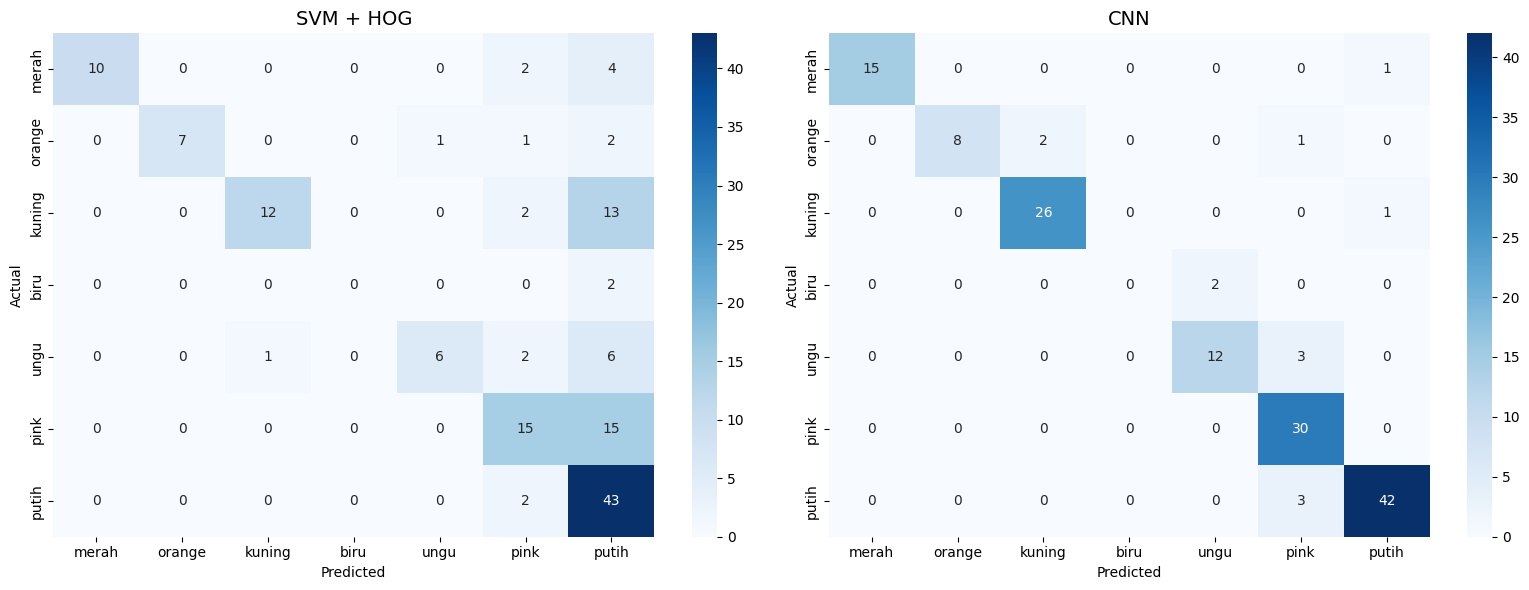

Disimpan: /content/drive/MyDrive/Computer Vision/Tugas 3/output/confusion_matrix.png


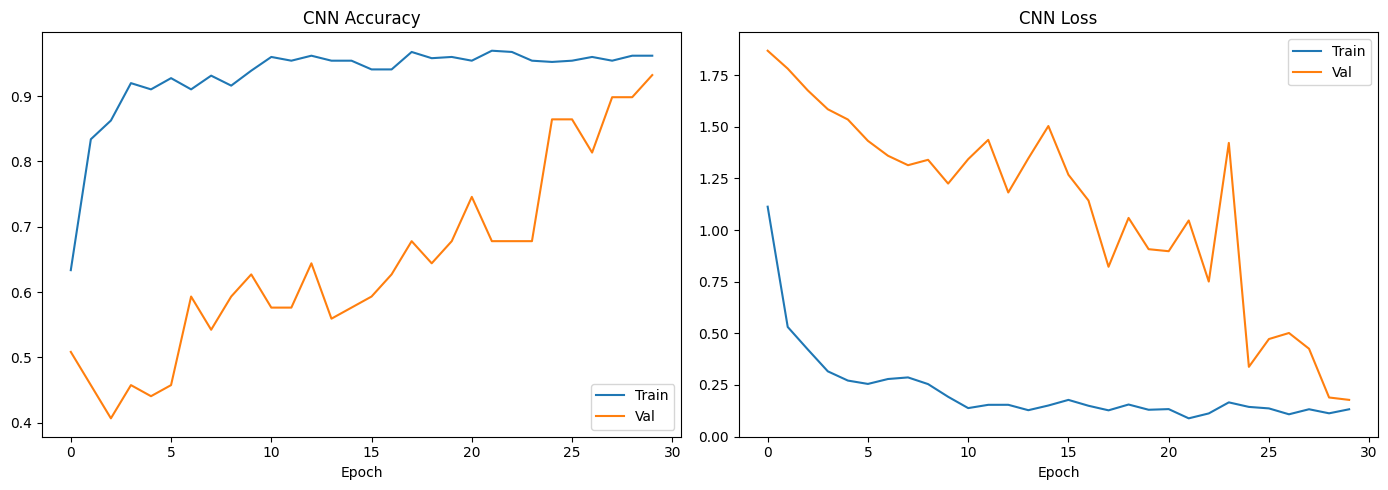

Disimpan: /content/drive/MyDrive/Computer Vision/Tugas 3/output/cnn_training_history.png


In [11]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_pred, title in zip(
    axes,
    [y_pred_svm, y_pred_cnn],
    ["SVM + HOG", "CNN"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Disimpan: {cm_path}")

# Training history CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
hist_path = os.path.join(OUTPUT_DIR, "cnn_training_history.png")
plt.savefig(hist_path, dpi=150)
plt.show()
print(f"Disimpan: {hist_path}")

In [12]:
#Simpan Model & Hasil ke GDrive

# SVM
svm_path = os.path.join(OUTPUT_DIR, "model_svm_hog.pkl")
joblib.dump(svm_pipeline, svm_path)
print(f"Model SVM disimpan : {svm_path}")

# CNN
cnn_path = os.path.join(OUTPUT_DIR, "model_cnn.keras")
cnn_model.save(cnn_path)
print(f"Model CNN disimpan : {cnn_path}")

# Hasil metrik JSON
results = {
    "SVM_HOG": {
        "akurasi":            round(acc_svm,  4),
        "precision":          round(prec_svm, 4),
        "recall":             round(rec_svm,  4),
        "f1_score":           round(f1_svm,   4),
        "waktu_training_s":   round(svm_train_time, 2),
        "waktu_inferensi_ms": round(svm_infer_time * 1000, 4)
    },
    "CNN": {
        "akurasi":            round(acc_cnn,  4),
        "precision":          round(prec_cnn, 4),
        "recall":             round(rec_cnn,  4),
        "f1_score":           round(f1_cnn,   4),
        "waktu_training_s":   round(cnn_train_time, 2),
        "waktu_inferensi_ms": round(cnn_infer_time * 1000, 4)
    }
}
json_path = os.path.join(OUTPUT_DIR, "hasil_evaluasi.json")
with open(json_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Hasil evaluasi disimpan : {json_path}")

Model SVM disimpan : /content/drive/MyDrive/Computer Vision/Tugas 3/output/model_svm_hog.pkl
Model CNN disimpan : /content/drive/MyDrive/Computer Vision/Tugas 3/output/model_cnn.keras
Hasil evaluasi disimpan : /content/drive/MyDrive/Computer Vision/Tugas 3/output/hasil_evaluasi.json


In [13]:
#Simpan Hasil Klasifikasi per Gambar (CSV)

import pandas as pd

df_hasil = pd.DataFrame({
    "label_asli":    [CLASS_NAMES[i] for i in y_test],
    "prediksi_svm":  [CLASS_NAMES[i] for i in y_pred_svm],
    "prediksi_cnn":  [CLASS_NAMES[i] for i in y_pred_cnn],
    "benar_svm":     y_test == y_pred_svm,
    "benar_cnn":     y_test == y_pred_cnn,
})

csv_path = os.path.join(OUTPUT_DIR, "hasil_klasifikasi.csv")
df_hasil.to_csv(csv_path, index=False)
print(f"CSV disimpan: {csv_path}")
print(df_hasil.head(10))

CSV disimpan: /content/drive/MyDrive/Computer Vision/Tugas 3/output/hasil_klasifikasi.csv
  label_asli prediksi_svm prediksi_cnn  benar_svm  benar_cnn
0     kuning        putih       kuning      False       True
1       pink         pink         pink       True       True
2     kuning        putih       kuning      False       True
3       pink         pink         pink       True       True
4      putih        putih        putih       True       True
5       ungu         pink         ungu      False       True
6      putih        putih        putih       True       True
7      merah        merah        merah       True       True
8     orange       orange       orange       True       True
9      putih        putih        putih       True       True


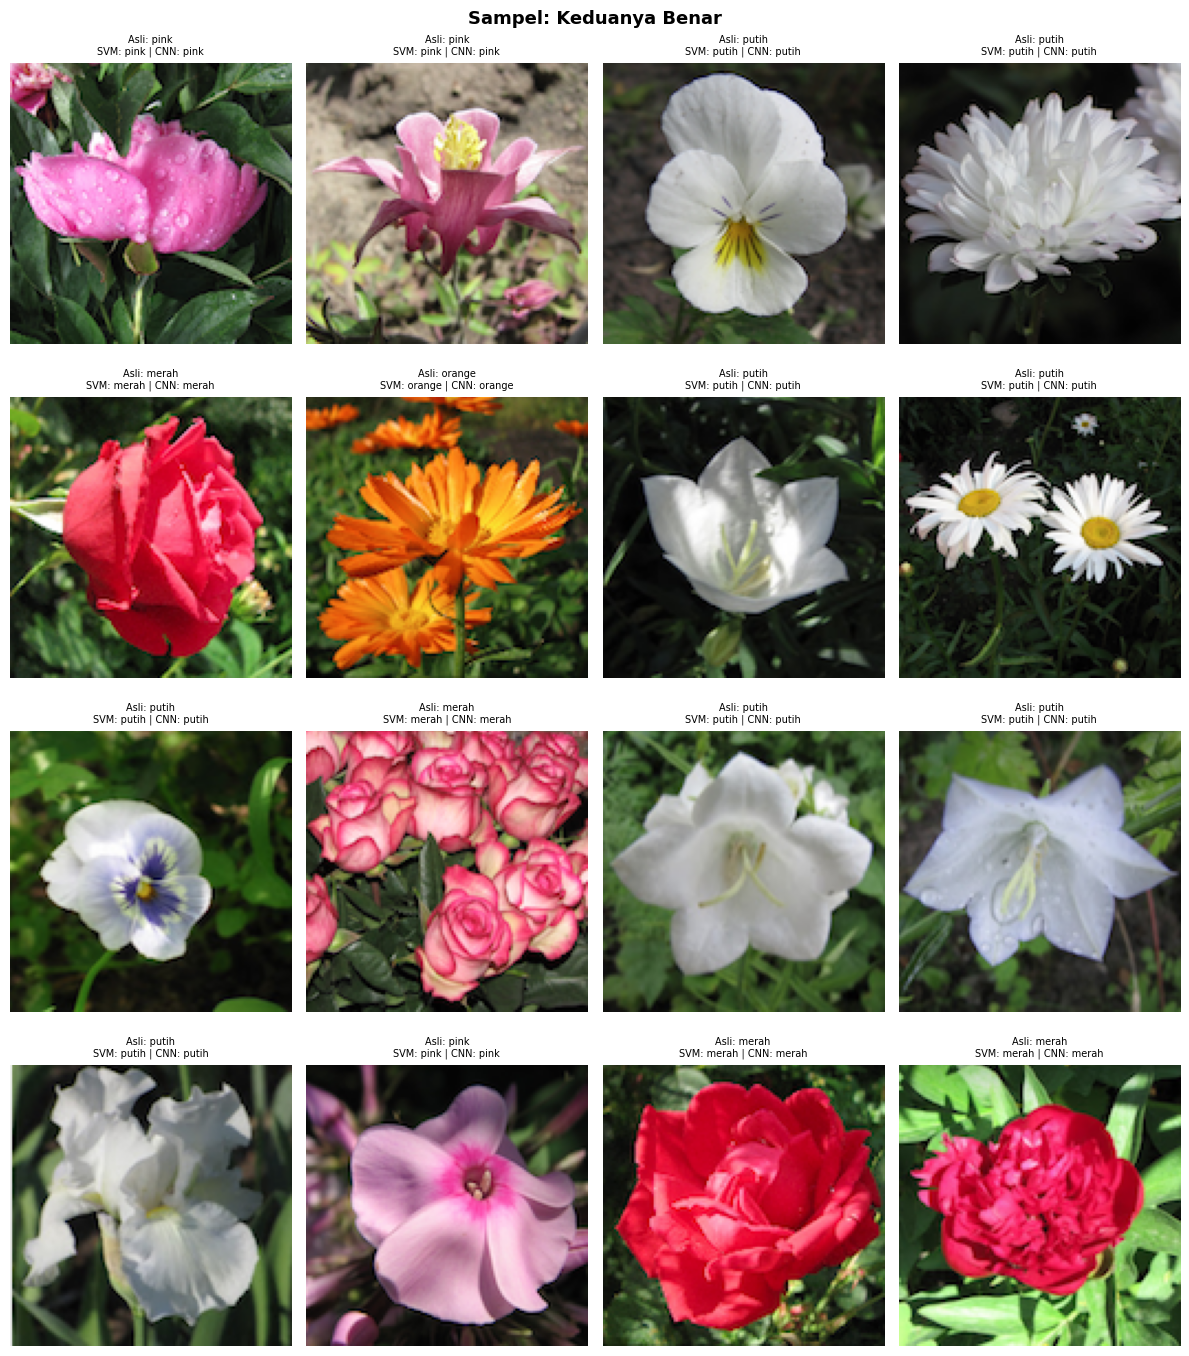

Disimpan: /content/drive/MyDrive/Computer Vision/Tugas 3/output/sampel_keduanya_benar.png


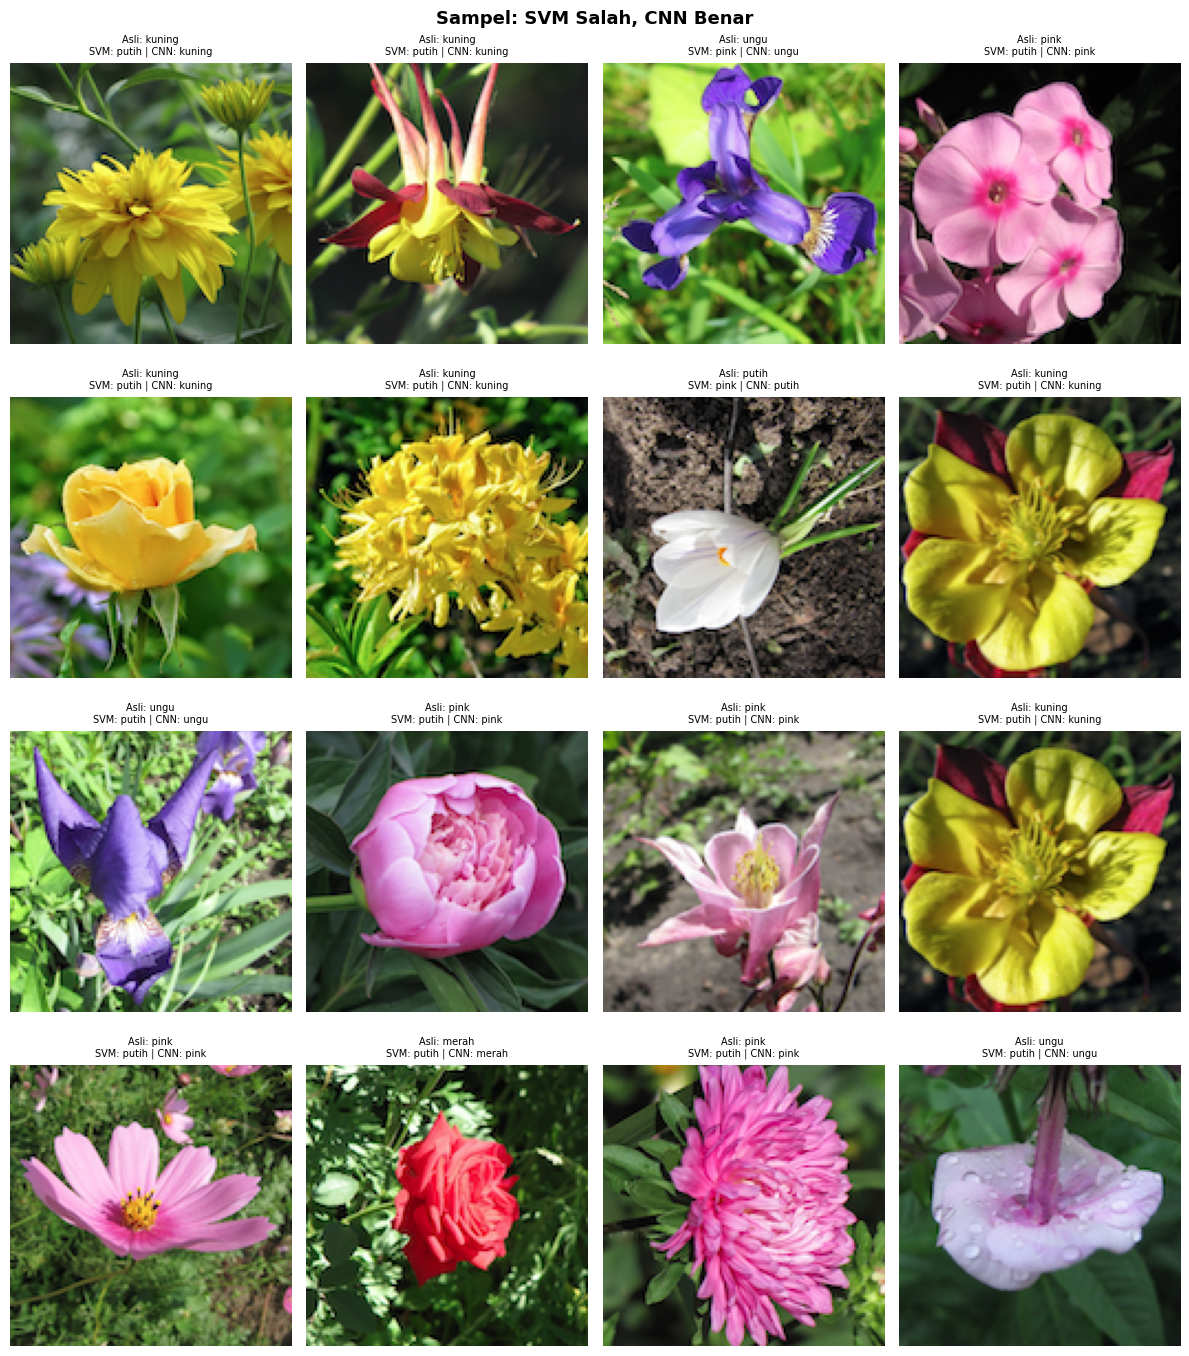

Disimpan: /content/drive/MyDrive/Computer Vision/Tugas 3/output/sampel_svm_salah_cnn_benar.png


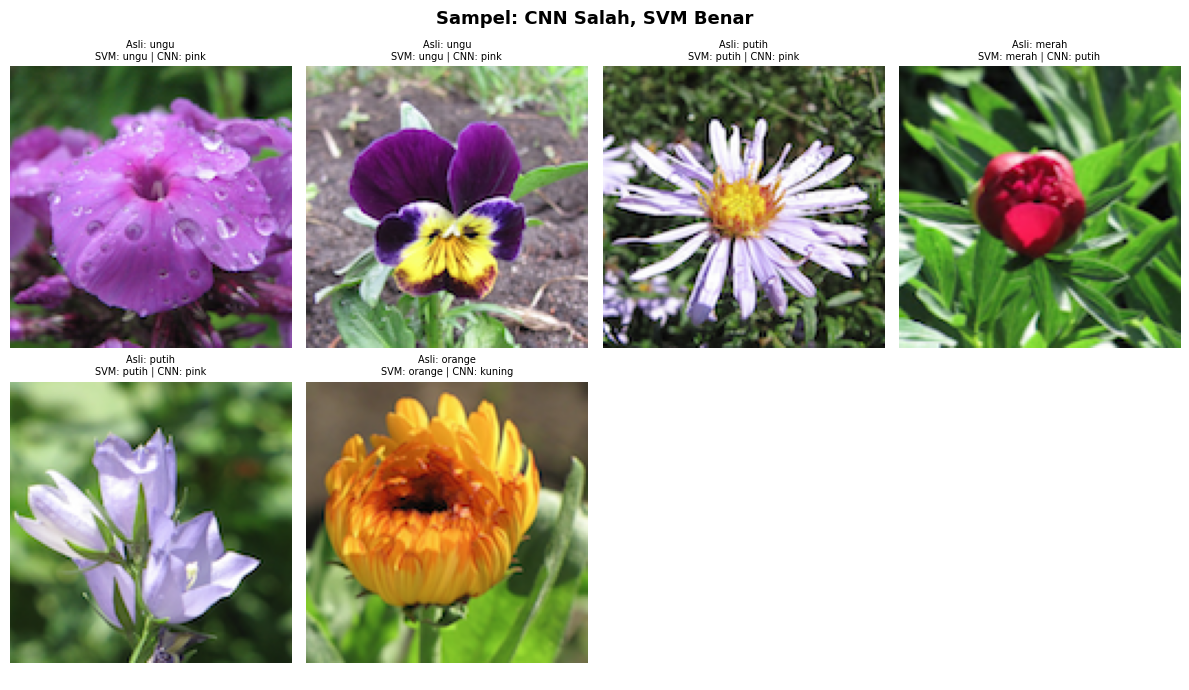

Disimpan: /content/drive/MyDrive/Computer Vision/Tugas 3/output/sampel_cnn_salah_svm_benar.png


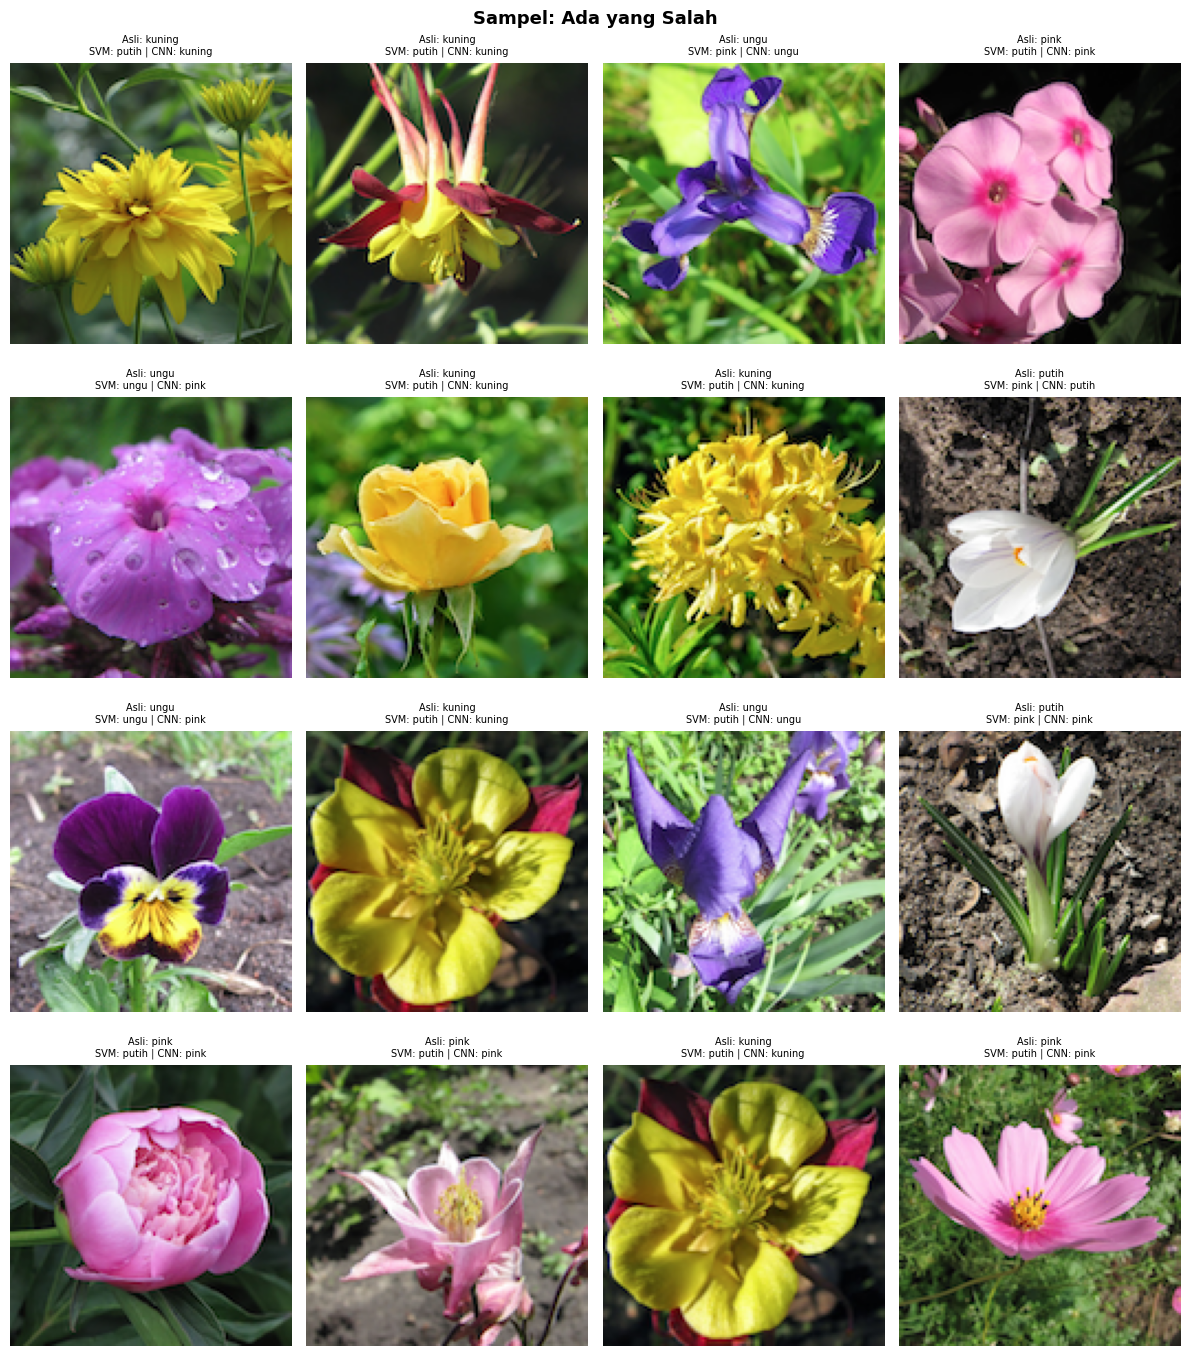

Disimpan: /content/drive/MyDrive/Computer Vision/Tugas 3/output/sampel_keduanya_salah.png


In [14]:
# Sampel Visual Hasil Klasifikasi

def plot_samples(X, y_true, y_pred_svm, y_pred_cnn,
                 class_names, mode="benar", n=16, save_name="sampel.png"):
    """
    mode: 'benar'  → gambar yang KEDUANYA benar
          'salah'  → gambar yang salah di salah satu atau keduanya
          'svm_salah' → SVM salah tapi CNN benar
          'cnn_salah' → CNN salah tapi SVM benar
    """
    if mode == "benar":
        idx = np.where((y_true == y_pred_svm) & (y_true == y_pred_cnn))[0]
    elif mode == "salah":
        idx = np.where((y_true != y_pred_svm) | (y_true != y_pred_cnn))[0]
    elif mode == "svm_salah":
        idx = np.where((y_true != y_pred_svm) & (y_true == y_pred_cnn))[0]
    elif mode == "cnn_salah":
        idx = np.where((y_true == y_pred_svm) & (y_true != y_pred_cnn))[0]

    idx = idx[:n]
    cols = 4
    rows = int(np.ceil(len(idx) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i >= len(idx):
            ax.axis("off")
            continue
        img_rgb = X[idx[i]][..., ::-1]
        ax.imshow(img_rgb.astype(np.uint8))
        ax.axis("off")

        true_label = class_names[y_true[idx[i]]]
        svm_label  = class_names[y_pred_svm[idx[i]]]
        cnn_label  = class_names[y_pred_cnn[idx[i]]]

        svm_color = "green" if svm_label == true_label else "red"
        cnn_color = "green" if cnn_label == true_label else "red"

        ax.set_title(
            f"Asli: {true_label}\n"
            f"SVM: {svm_label} | CNN: {cnn_label}",
            fontsize=7,
            color="black"
        )
        # Warna border kotak gambar
        for spine in ax.spines.values():
            if svm_label == true_label and cnn_label == true_label:
                spine.set_edgecolor("green")
            elif svm_label != true_label and cnn_label != true_label:
                spine.set_edgecolor("red")
            else:
                spine.set_edgecolor("orange")
            spine.set_linewidth(2)

    plt.suptitle({
        "benar":      "Sampel: Keduanya Benar",
        "salah":      "Sampel: Ada yang Salah",
        "svm_salah":  "Sampel: SVM Salah, CNN Benar",
        "cnn_salah":  "Sampel: CNN Salah, SVM Benar",
    }[mode], fontsize=13, fontweight="bold")

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Disimpan: {save_path}")

# Plot 4 skenario
plot_samples(X_test, y_test, y_pred_svm, y_pred_cnn,
             CLASS_NAMES, mode="benar",     n=16, save_name="sampel_keduanya_benar.png")

plot_samples(X_test, y_test, y_pred_svm, y_pred_cnn,
             CLASS_NAMES, mode="svm_salah", n=16, save_name="sampel_svm_salah_cnn_benar.png")

plot_samples(X_test, y_test, y_pred_svm, y_pred_cnn,
             CLASS_NAMES, mode="cnn_salah", n=16, save_name="sampel_cnn_salah_svm_benar.png")

plot_samples(X_test, y_test, y_pred_svm, y_pred_cnn,
             CLASS_NAMES, mode="salah",     n=16, save_name="sampel_keduanya_salah.png")

In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio python-multipart

In [ ]:
import nest_asyncio
import uvicorn
import numpy as np
import cv2
import joblib
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
from pyngrok import ngrok, conf
import tensorflow as tf
import threading

# ── Ganti dengan token ngrok kamu ──
NGROK_TOKEN = "3EqvPAr8VkWmTTVTf45w6bS0Lqe_722qdqTjFyzbQp7JpmWrL"
conf.get_default().auth_token = NGROK_TOKEN

# ── Path model dari Cell 11 ──
SVM_PATH = "/content/drive/MyDrive/Computer Vision/Tugas 3/output/model_svm_hog.pkl"
CNN_PATH  = "/content/drive/MyDrive/Computer Vision/Tugas 3/output/model_cnn.keras"

CLASS_NAMES = ["merah", "orange", "kuning", "biru", "ungu", "pink", "putih"]
IMG_SIZE    = 128

# ── Load model ──
print("Loading model SVM...")
svm_pipeline = joblib.load(SVM_PATH)
print("Loading model CNN...")
cnn_model = tf.keras.models.load_model(CNN_PATH)
print("Model siap.")

# ── HOG extractor ──
from skimage.feature import hog
def extract_hog_single(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    feat = hog(gray, orientations=9,
               pixels_per_cell=(8,8),
               cells_per_block=(2,2),
               visualize=False)
    return feat.reshape(1, -1)

# ── FastAPI app ──
app = FastAPI()
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    np_arr   = np.frombuffer(contents, np.uint8)
    img      = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    if img is None:
        return JSONResponse({"error": "Gambar tidak valid"}, status_code=400)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Prediksi SVM
    hog_feat      = extract_hog_single(img)
    svm_idx       = svm_pipeline.predict(hog_feat)[0]
    svm_proba     = svm_pipeline.predict_proba(hog_feat)[0]
    svm_label     = CLASS_NAMES[svm_idx]
    svm_confidence = round(float(svm_proba[svm_idx]) * 100, 2)

    # Prediksi CNN
    img_rgb   = img[..., ::-1].astype(np.float32)
    img_input = np.expand_dims(img_rgb, axis=0)
    cnn_proba = cnn_model.predict(img_input, verbose=0)[0]
    cnn_idx   = int(np.argmax(cnn_proba))
    cnn_label = CLASS_NAMES[cnn_idx]
    cnn_confidence = round(float(cnn_proba[cnn_idx]) * 100, 2)

    return {
        "svm": {"label": svm_label, "confidence": svm_confidence},
        "cnn": {"label": cnn_label, "confidence": cnn_confidence},
    }

# ── Jalankan server ──
nest_asyncio.apply()
public_url = ngrok.connect(8000)
print(f"\nAPI URL: {public_url}")
print("Salin URL di atas, paste ke file HTML nanti.\n")

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()